# PC flow mapping — minimal

Self-contained: no imports from `pc_flow.py` or `koopman_gravity.py`. Everything needed to load
the data, fit the Koopman operator on each PC plane, and draw the two standard plots — measured
movement arrows and attracting/repelling regions — lives in this notebook.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

plt.style.use("seaborn-v0_8-white")

PC_COLUMNS = [f"PC{i}" for i in range(1, 7)]
FIG_DIR = "figures/pc_flow_mapping_new"
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load the PC data

One row per (vase, PC) in the file; pivot to one row per vase.

In [2]:
def load_pc_wide(path):
    df = pd.read_parquet(path)
    wide = (
        df.drop_duplicates(["participant_id", "generation_key", "vase", "pc_name"])
        .pivot_table(
            index=["participant_id", "play_counter", "generation_key", "vase",
                   "is_selected_vase", "is_parent_vase"],
            columns="pc_name", values="pc_value",
        )
        .reset_index()
    )
    wide["generation_num"] = wide["generation_key"].str.extract(r"gen_(\d+)").astype(int)
    wide["vase_id"] = wide["participant_id"] + "::" + wide["generation_key"] + "::" + wide["vase"]
    return wide.sort_values(["participant_id", "play_counter", "generation_num", "vase"]).reset_index(drop=True)


wide = load_pc_wide("../file_processing/processed/pc_data.parquet")
print(f"{len(wide):,} vase records, {wide.participant_id.nunique():,} participants")
wide[["vase_id", "generation_num", "vase", "is_selected_vase", "is_parent_vase"] + PC_COLUMNS].head()

136,200 vase records, 2,724 participants


pc_name,vase_id,generation_num,vase,is_selected_vase,is_parent_vase,PC1,PC2,PC3,PC4,PC5,PC6
0,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,1,vase_1,True,False,-5.394564,-6.499860,-4.823126,-0.503813,3.943664,-1.677248
1,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,1,vase_2,False,False,-4.928885,-1.448066,1.944108,-5.222136,4.495899,1.447776
2,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,2,vase_1,True,True,-5.394564,-6.499860,-4.823126,-0.503813,3.943664,-1.677248
3,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,2,vase_2,False,False,-2.176003,-8.944311,-0.651577,0.098739,4.974857,-3.268349
4,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,3,vase_1,False,True,-5.394564,-6.499860,-4.823126,-0.503813,3.943664,-1.677248


## 2. Champion transitions and matchups

Transitions include retained champions (zero-length steps) — a process that stops moving is
exactly what an attractor looks like; dropping them would bias the fit towards motion. Matchups
are every head-to-head comparison, used only to fix the sign of the eigenfunction.

In [3]:
def build_champion_transitions(wide):
    keys = ["participant_id", "play_counter"]
    win = wide.loc[wide.is_selected_vase, keys + ["generation_num", "vase_id"]].sort_values(keys + ["generation_num"])
    nxt = win.rename(columns={"vase_id": "child_vase_id"}).copy()
    nxt["generation_num"] -= 1
    edges = (win.rename(columns={"vase_id": "parent_vase_id"})
             .merge(nxt, on=keys + ["generation_num"], how="inner")
             .reset_index(drop=True))
    edges["generation_num"] += 1          # relabel from source generation to destination generation
    return edges


def build_pc_matchups(wide):
    keys = ["participant_id", "play_counter", "generation_num"]
    win = wide.loc[wide.is_selected_vase, keys + ["vase_id"]].rename(columns={"vase_id": "winner_vase_id"})
    lose = wide.loc[~wide.is_selected_vase, keys + ["vase_id"]].rename(columns={"vase_id": "loser_vase_id"})
    return win.merge(lose, on=keys, how="inner").reset_index(drop=True)


edges = build_champion_transitions(wide)
matchups = build_pc_matchups(wide)
print(f"champion transitions: {len(edges):,}   head-to-head matchups: {len(matchups):,}")

champion transitions: 54,480   head-to-head matchups: 68,100


## 3. Koopman operator

Gaussian RBF lift of the 2-D plane into a basis of `n_basis²` functions, a ridge-regularised
least-squares fit of the operator `K`, and its slowest non-trivial eigenfunction (mode 1 — mode 0
is the ~invariant occupancy density and carries no direction). The ridge is not optional: the RBF
Gram matrix is near-singular, and without it the spectrum is numerical noise rather than physics.
The eigenfunction's sign is arbitrary, so it is oriented so the higher-Φ vase is the one people
actually chose, judged across every matchup.

In [4]:
def rbf_lift(xy, centres, sigma):
    """(2, N) points -> (n_rbf, N) Gaussian RBF features."""
    d2 = np.sum((xy.T[:, None, :] - centres[None, :, :]) ** 2, axis=2)
    return np.exp(-d2 / (2 * sigma ** 2)).T


def fit_koopman(Z, Z_prime, centres, sigma, ridge=1e-3):
    """K such that psi(Z_prime) ~= K psi(Z), by ridge-regularised least squares on the Gram matrices."""
    psi, psi_prime = rbf_lift(Z, centres, sigma), rbf_lift(Z_prime, centres, sigma)
    A = psi @ psi.T
    B = psi_prime @ psi.T
    A += ridge * (np.trace(A) / len(centres)) * np.eye(len(centres))
    return np.linalg.solve(A.T, B.T).T          # K A = B  =>  K = B A^-1


def slow_mode(K):
    """Eigenvalue/eigenvector of the slowest non-trivial mode (mode 1, by |eigenvalue|)."""
    evals, evecs = np.linalg.eig(K)
    idx = np.argsort(-np.abs(evals))[1]
    return evals[idx].real, np.real(evecs[:, idx])


def gravity(xy, evec, centres, sigma):
    """Evaluate the eigenfunction (the gravity field) at each point in xy, shape (2, N)."""
    return (evec @ rbf_lift(xy, centres, sigma)).real

## 4. Fit each PC plane

Bounds are clipped to the 0.5th-99.5th percentile — PC scores have long tails, so the raw extremes
would spend most of the basis on a handful of outliers.

Restricted to the three paired axes PC1/PC2, PC3/PC4, PC5/PC6 — the natural pairing from PCA
component order, rather than all 15 combinations.

In [5]:
def fit_plane(pc_x, pc_y, n_basis=15, n_eval=40, ridge=1e-3, drift_grid=16, min_count=25, q=0.005):
    coords = wide.drop_duplicates("vase_id").set_index("vase_id")[[pc_x, pc_y]]
    x_min, x_max = wide[pc_x].quantile(q), wide[pc_x].quantile(1 - q)
    y_min, y_max = wide[pc_y].quantile(q), wide[pc_y].quantile(1 - q)

    # --- RBF basis and Koopman fit ---
    gx, gy = np.meshgrid(np.linspace(x_min, x_max, n_basis), np.linspace(y_min, y_max, n_basis))
    centres = np.column_stack([gx.ravel(), gy.ravel()])
    sigma = np.median(NearestNeighbors(n_neighbors=2).fit(centres).kneighbors(centres)[0][:, 1])

    parent = coords.reindex(edges.parent_vase_id).to_numpy()
    child = coords.reindex(edges.child_vase_id).to_numpy()
    K = fit_koopman(parent.T, child.T, centres, sigma, ridge)
    eigenvalue, evec = slow_mode(K)
    spectral_radius = np.abs(np.linalg.eigvals(K)).max()

    # --- orient the sign so the higher-gravity vase is the one people chose ---
    phi_by_vase = pd.Series(gravity(coords.to_numpy().T, evec, centres, sigma), index=coords.index)
    d = (phi_by_vase.reindex(matchups.winner_vase_id).to_numpy()
         - phi_by_vase.reindex(matchups.loser_vase_id).to_numpy())
    win_rate = float((d > 0).mean())
    if win_rate < 0.5:
        evec, win_rate = -evec, 1 - win_rate

    # --- gravity field on a dense grid, for the attracting/repelling contours ---
    ex, ey = np.meshgrid(np.linspace(x_min, x_max, n_eval), np.linspace(y_min, y_max, n_eval))
    phi_2d = gravity(np.vstack([ex.ravel(), ey.ravel()]), evec, centres, sigma).reshape(ex.shape)

    # --- gradient of the fitted potential: which way Phi rises, and how steeply ---
    dx = ex[0, 1] - ex[0, 0]
    dy = ey[1, 0] - ey[0, 0]
    V, U = np.gradient(phi_2d, dy, dx)

    # --- measured drift: mean observed displacement per cell (cells with <min_count transitions dropped) ---
    x_edges = np.linspace(x_min, x_max, drift_grid + 1)
    y_edges = np.linspace(y_min, y_max, drift_grid + 1)
    ix = np.clip(np.searchsorted(x_edges, parent[:, 0]) - 1, 0, drift_grid - 1)
    iy = np.clip(np.searchsorted(y_edges, parent[:, 1]) - 1, 0, drift_grid - 1)
    dU, dV, C = (np.zeros((drift_grid, drift_grid)) for _ in range(3))
    np.add.at(dU, (iy, ix), child[:, 0] - parent[:, 0])
    np.add.at(dV, (iy, ix), child[:, 1] - parent[:, 1])
    np.add.at(C, (iy, ix), 1)
    keep = C >= min_count
    dU = np.where(keep, dU / np.maximum(C, 1), np.nan)
    dV = np.where(keep, dV / np.maximum(C, 1), np.nan)
    drift_x, drift_y = np.meshgrid(0.5 * (x_edges[:-1] + x_edges[1:]), 0.5 * (y_edges[:-1] + y_edges[1:]))

    return dict(pc_x=pc_x, pc_y=pc_y, eigenvalue=eigenvalue, win_rate=win_rate,
                spectral_radius=spectral_radius, xlim=(x_min, x_max), ylim=(y_min, y_max),
                eval_x=ex, eval_y=ey, phi_2d=phi_2d, U=U, V=V,
                drift_x=drift_x, drift_y=drift_y, drift_u=dU, drift_v=dV)


PAIRS = [("PC1", "PC2"), ("PC3", "PC4"), ("PC5", "PC6")]

results = {}
for pc_x, pc_y in PAIRS:
    r = fit_plane(pc_x, pc_y)
    results[(pc_x, pc_y)] = r
    flag = "" if r["spectral_radius"] < 1.05 else "  <- non-physical, check ridge"
    print(f"  {pc_x} vs {pc_y}:  lambda={r['eigenvalue']:.4f}  win_rate={r['win_rate']:.4f}  "
          f"spectral_radius={r['spectral_radius']:.4f}{flag}")

  PC1 vs PC2:  lambda=0.9639  win_rate=0.5469  spectral_radius=0.9834


  PC3 vs PC4:  lambda=0.9645  win_rate=0.5462  spectral_radius=0.9952


  PC5 vs PC6:  lambda=0.9692  win_rate=0.5269  spectral_radius=0.9936


## 5. Plot: attracting/repelling regions with the gravity flow

Styled to match `trajectory_mapping_og.ipynb`'s gravity map. Filled contour is the gravity field
Φ — red/high is where the selection process settles (attracting), blue/low is where it does not
(repelling), colour-centred at Φ=0 per plane rather than a plain min/max scale (a plain scale lets
a single deep basin push most of a plane into one colour — PC1/PC2's minimum is -1.32 but 93% of
its grid sits above the midpoint of its range, which is what made it read as almost entirely red
before this fix). Purple streamlines trace the gradient of the fitted potential: which way Φ rises
and how steeply. They are the fitted field's direction, not measured champion movement.

Each plane keeps its own colour range rather than sharing one across all three: Φ is an
eigenvector, and its scale is set independently by each plane's own fit, so a Φ of 0.5 on PC1/PC2
and a Φ of 0.5 on PC3/PC4 are not the same amount of anything. Centring every panel at zero makes
the *sign* (attracting vs repelling) comparable across planes; the *magnitude* is not, and forcing
one shared colour range on all three would either flatten the strongest plane or blow out the
weakest one.

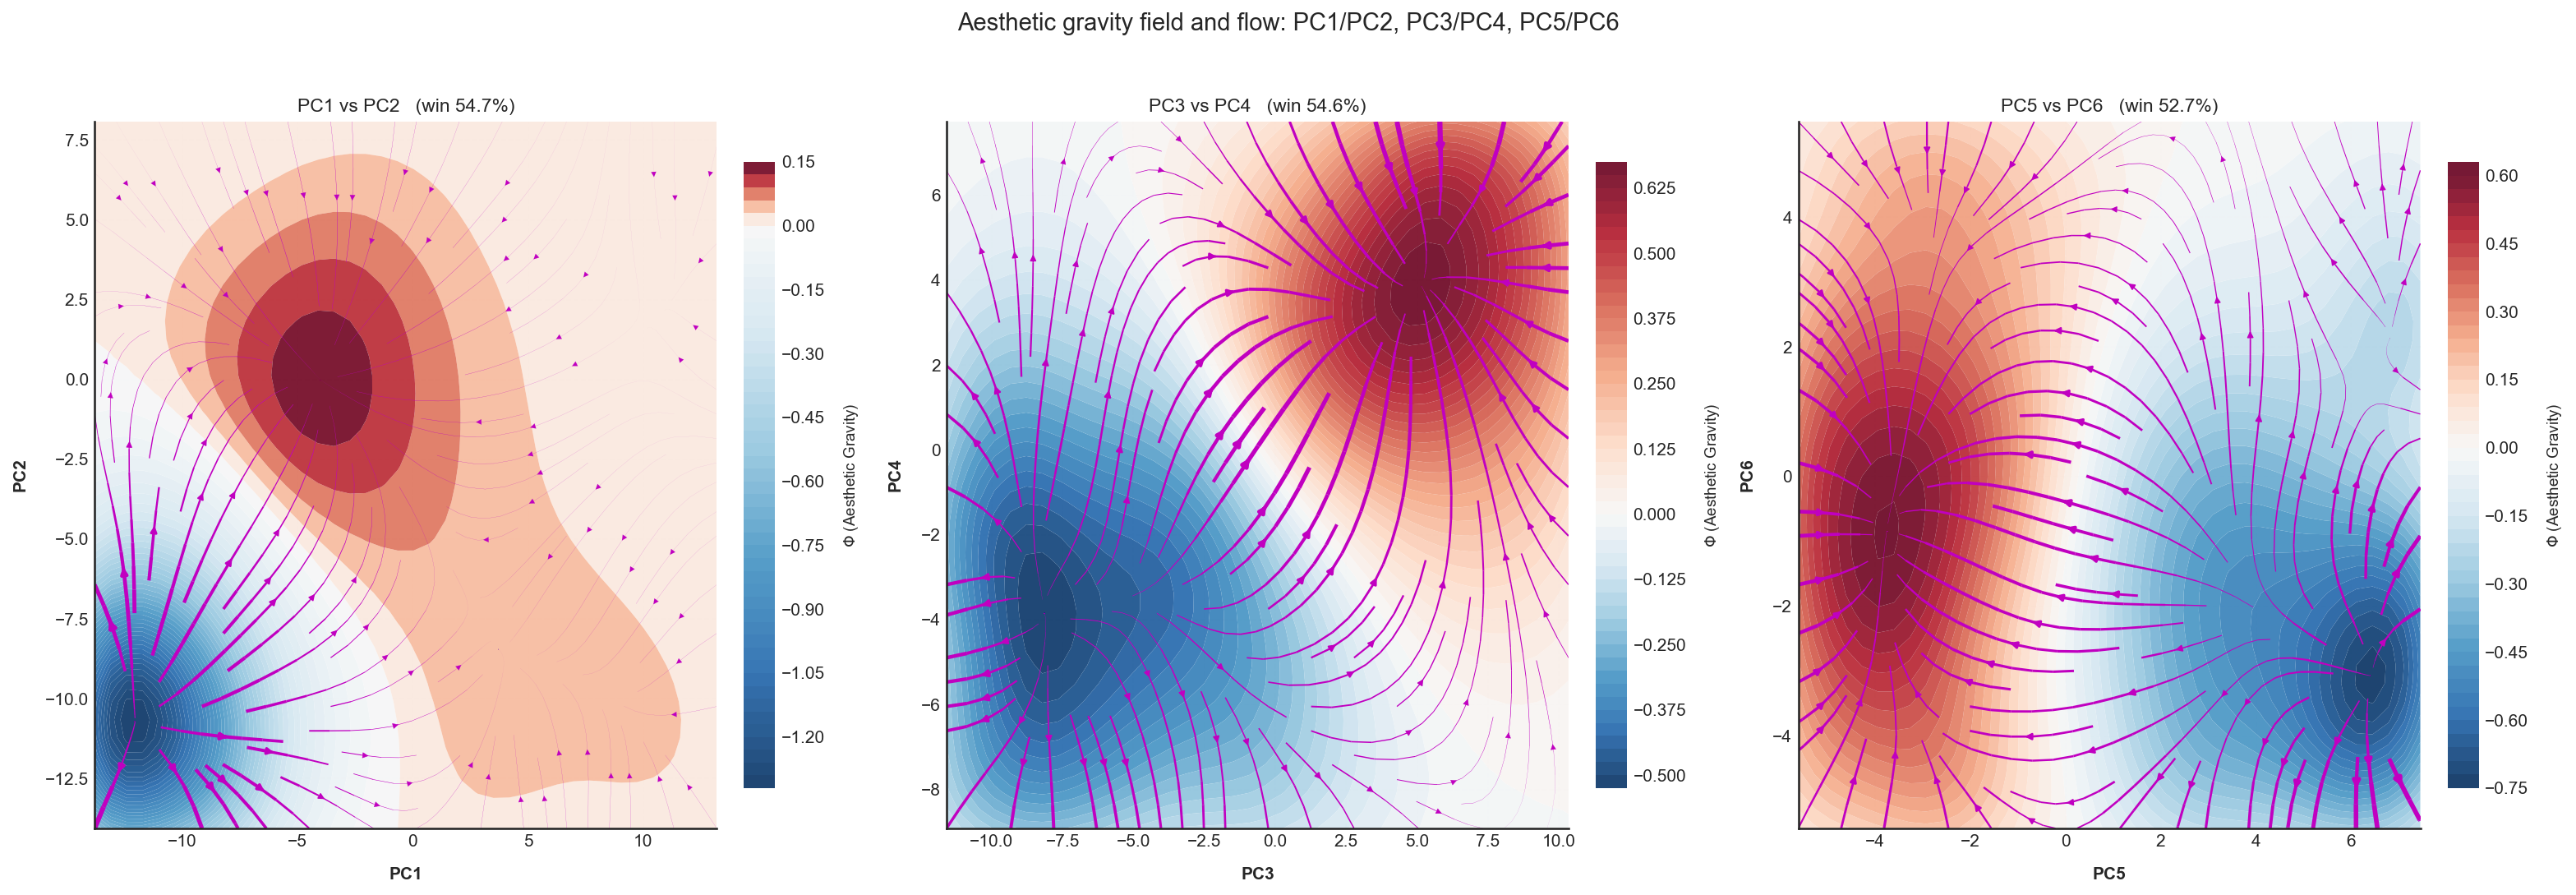

In [6]:
def plot_plane(ax, r, show_drift=False):
    # Centre the diverging colourmap at Phi=0 -- a plain min/max scale would place white at
    # the midpoint of the data range instead, which is not where "attracting vs repelling"
    # actually flips.
    vmin, vmax = np.nanmin(r["phi_2d"]), np.nanmax(r["phi_2d"])
    if vmin < 0 < vmax:
        norm = plt.matplotlib.colors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
    else:
        norm = plt.matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

    cf = ax.contourf(r["eval_x"], r["eval_y"], r["phi_2d"], levels=50, cmap="RdBu_r",
                     norm=norm, alpha=0.9, antialiased=True)

    speed = np.sqrt(r["U"] ** 2 + r["V"] ** 2)
    linewidth = 3 * speed / (speed.max() + 1e-9)
    ax.streamplot(r["eval_x"], r["eval_y"], r["U"], r["V"], color="#C000C0",
                  linewidth=linewidth, density=1, arrowstyle="-|>", arrowsize=0.75)

    if show_drift:
        m = ~np.isnan(r["drift_u"])
        ax.quiver(r["drift_x"][m], r["drift_y"][m], r["drift_u"][m], r["drift_v"][m],
                  color="#111111", angles="xy", scale_units="xy", scale=1.0,
                  width=0.005, headwidth=3.5, zorder=5)

    ax.set_xlim(*r["xlim"]); ax.set_ylim(*r["ylim"])
    ax.set_xlabel(r["pc_x"], fontweight="bold", labelpad=10)
    ax.set_ylabel(r["pc_y"], fontweight="bold", labelpad=10)
    ax.set_title(f"{r['pc_x']} vs {r['pc_y']}   (win {r['win_rate']:.1%})", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", color="#EEEEEE", alpha=0.5)
    return cf


order = sorted(results, key=lambda k: -results[k]["win_rate"])
fig, axes = plt.subplots(1, 3, figsize=(21, 7), dpi=150)
for ax, key in zip(axes.ravel(), order):
    cf = plot_plane(ax, results[key])
    cb = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cb.outline.set_visible(False)
    cb.set_label(r"$\Phi$ (Aesthetic Gravity)", fontsize=9, labelpad=10)
fig.suptitle("Aesthetic gravity field and flow: PC1/PC2, PC3/PC4, PC5/PC6", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "pc_flow_paired_planes.png"), dpi=200, bbox_inches="tight")
plt.show()

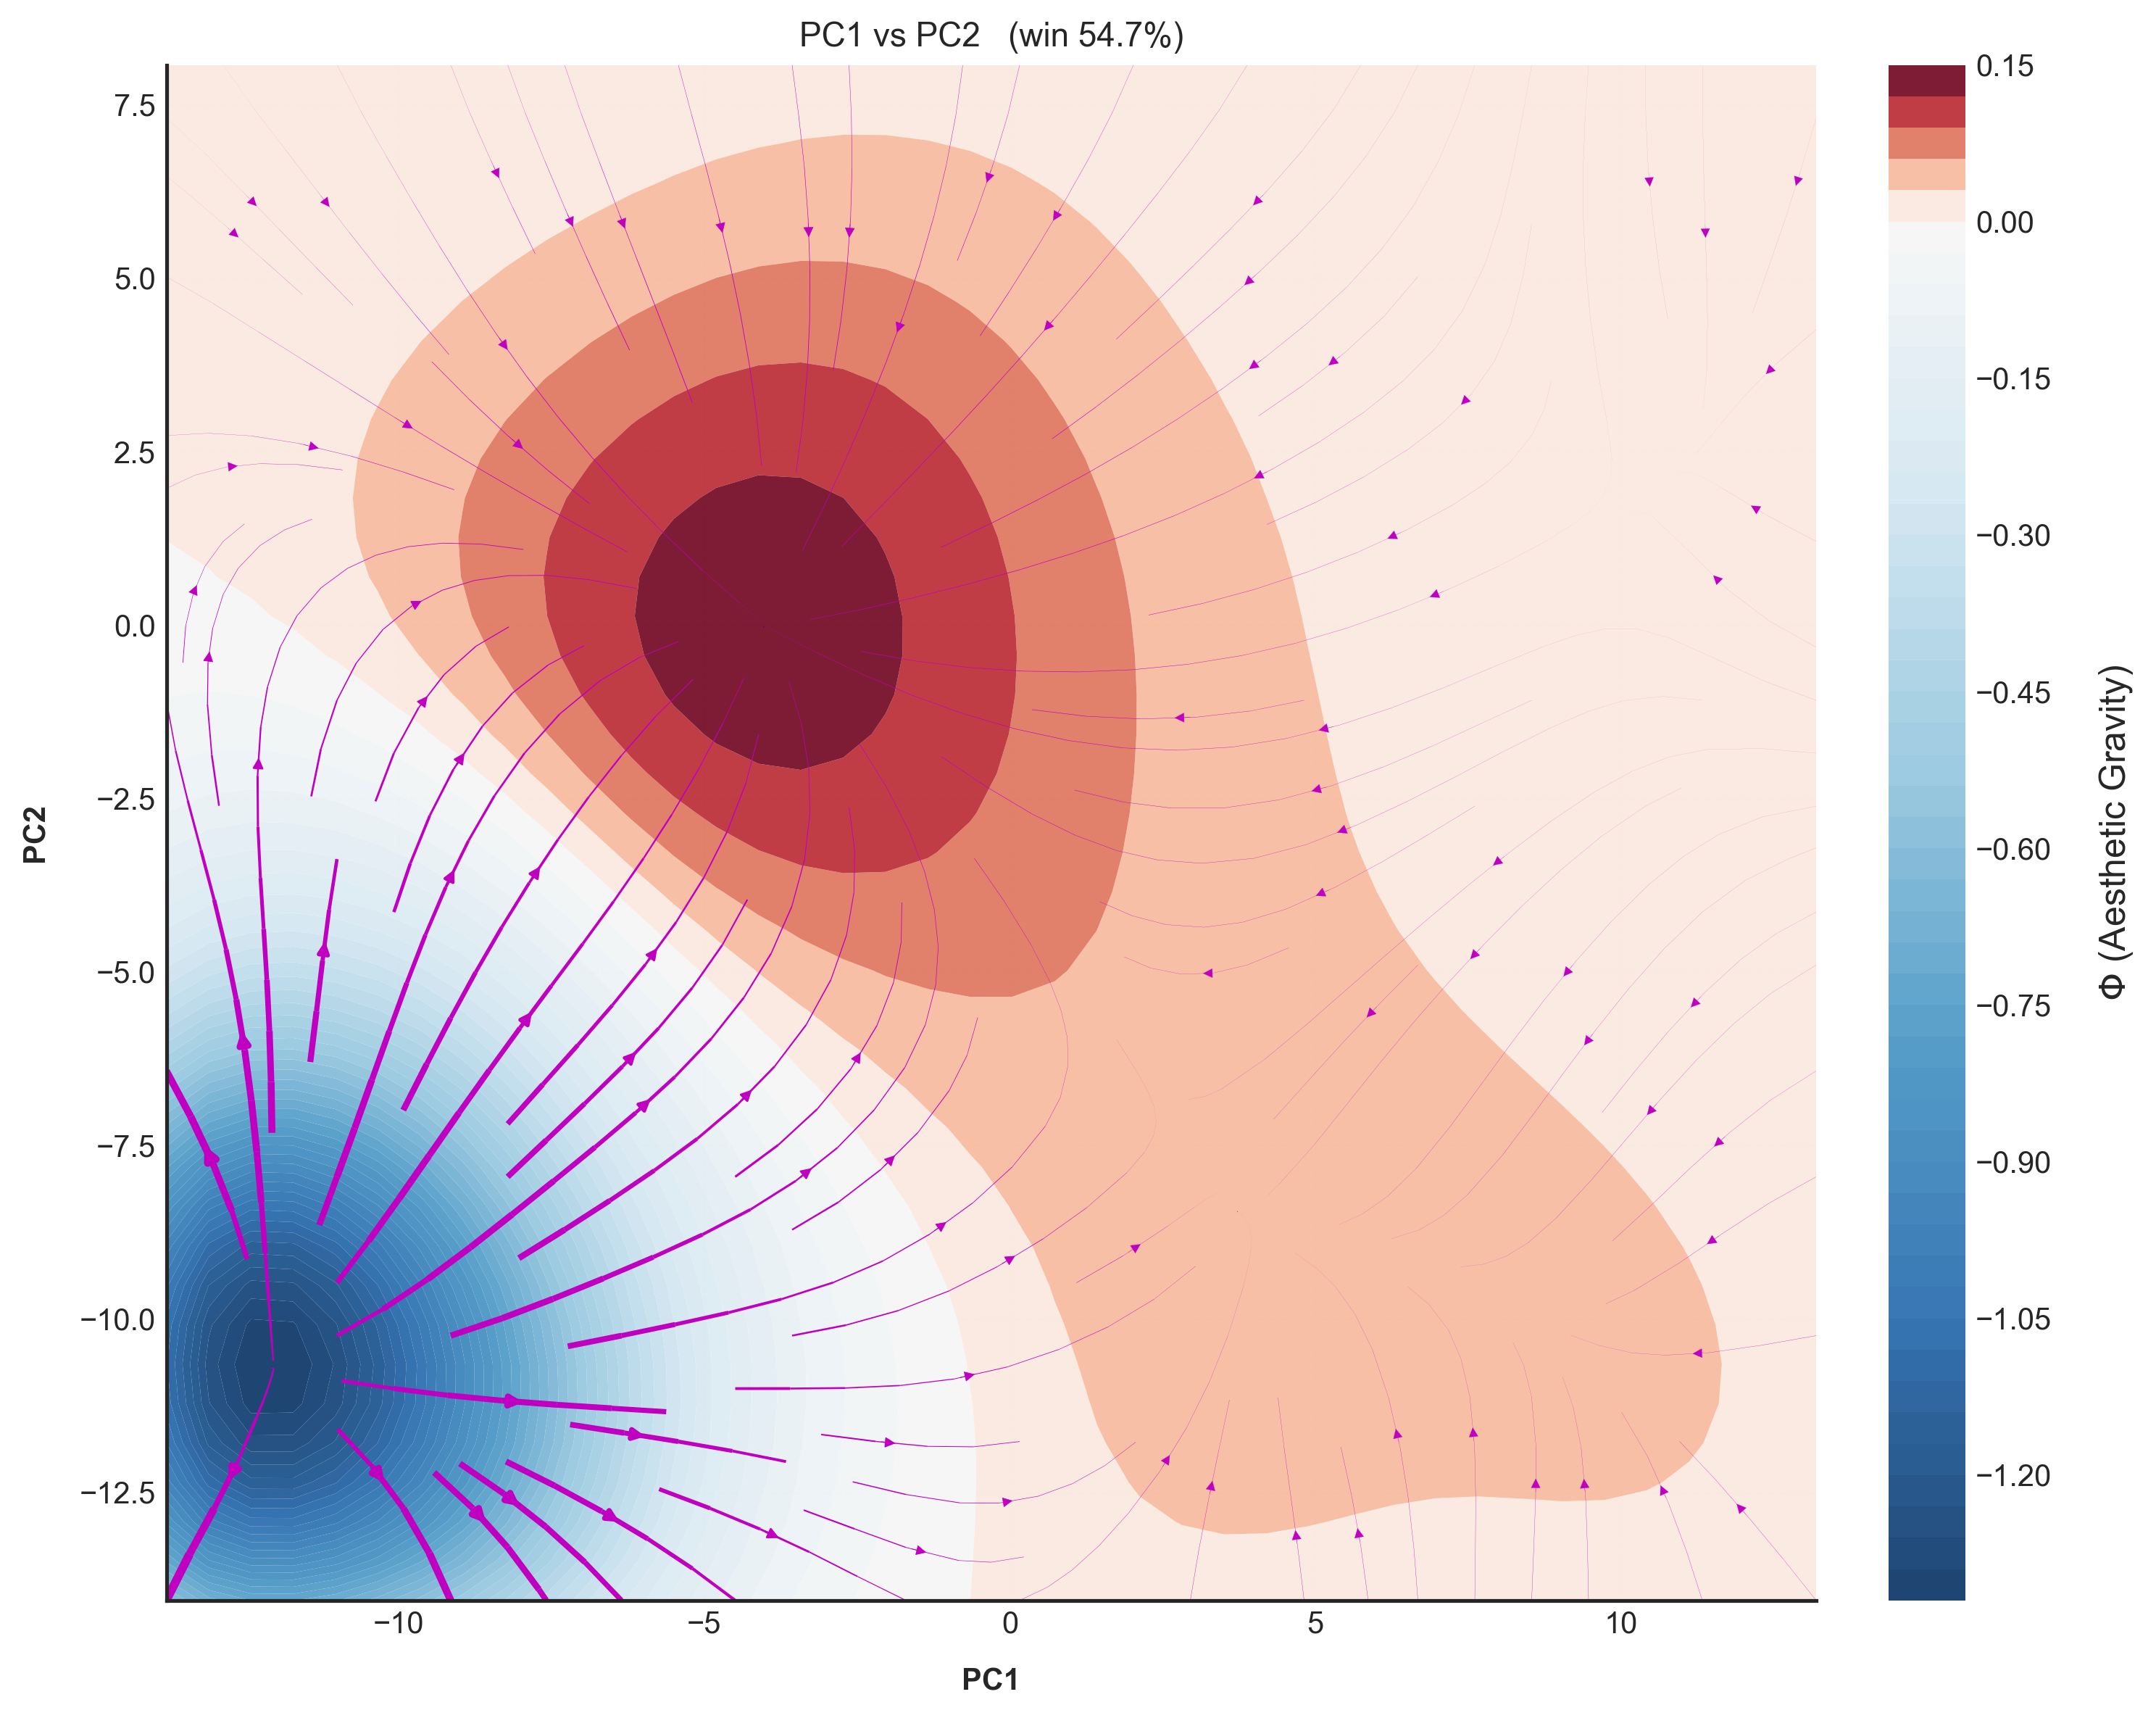

In [7]:
best = order[0]
r = results[best]

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
cf = plot_plane(ax, r)
cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label(r"$\Phi$ (Aesthetic Gravity)", fontsize=12, labelpad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"pc_flow_best_plane_{best[0]}_{best[1]}.png"), dpi=300, bbox_inches="tight")
plt.show()

## 6. Both together: measured movement and the fitted flow

Black arrows are the measured drift — mean observed displacement per cell, in PC units per
generation, cells with fewer than 25 transitions dropped. Purple streamlines are the gradient of
the fitted potential from section 5. They are different objects (one observed, one the fitted
field's slope) and mostly agree on direction; where they diverge is where the fit is least
trustworthy as a description of what people actually did.

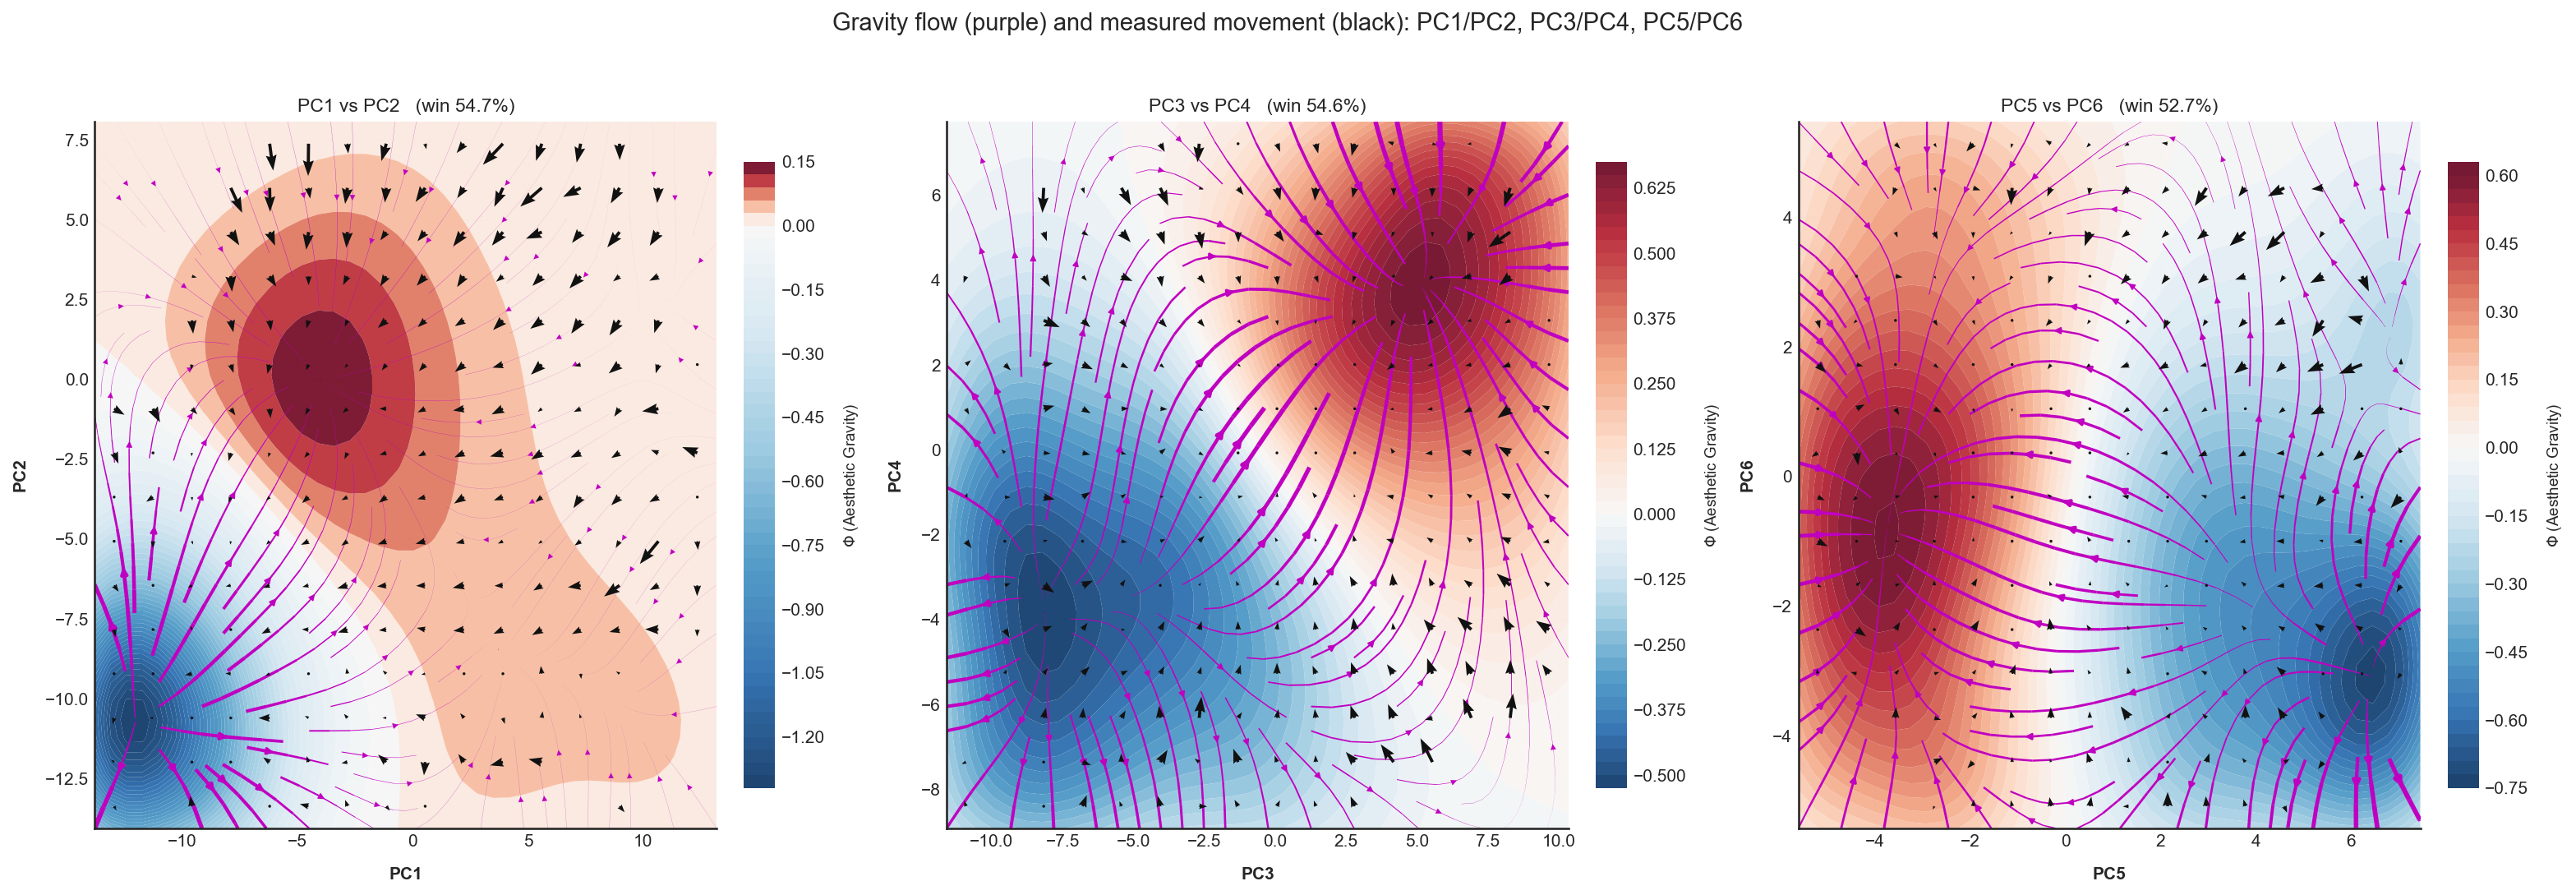

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7), dpi=150)
for ax, key in zip(axes.ravel(), order):
    cf = plot_plane(ax, results[key], show_drift=True)
    cb = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cb.outline.set_visible(False)
    cb.set_label(r"$\Phi$ (Aesthetic Gravity)", fontsize=9, labelpad=10)
fig.suptitle("Gravity flow (purple) and measured movement (black): PC1/PC2, PC3/PC4, PC5/PC6",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "pc_flow_paired_planes_with_drift.png"), dpi=200, bbox_inches="tight")
plt.show()